### 하이퍼파라미터
* 예측력을 높이기 위해 사용
* 과대/과소 적합을 방지하기 위해 사용
* 사용자가 지정하는 파라미터

#### 하이퍼파라미터 튜닝
* 특정 알고리즘의 매개변수 값을 변경하면서 최적의 파라미터를 찾는 방식
* GridSearchCV클래스를 통해 하이퍼파라미터 탐색과 교차 검증을 한번에 수행

#### GridSearchCV
* 교차 검증으로 하이퍼파라미터 탐색을 수행한다
* 최상의 모델을 찾은 후 훈련 세트 전체를 사용해 최종 모델을 훈련한다
* 매개변수
    - GridSearchCV(모델, param_grid = 파라미터, cv=반복횟수, n_jobs=코어 수(-1, 모든 코어 사용))

### K-최근접 이웃 알고리즘
* 주위에서 가장 가까운 다른 데이터를 보고 현재 데이터를 판단

#### 하이퍼파라미터
* n_neighbors
    - 기본 가까운 5개의 데이터를 보고 자기 자신이 어디에 속하는지를 판단
    - 비교하고자 하는 데이터의 수가 적을 수록 과대 적합이 된다
* metric : 거리계산 척도
    - euclidean(녹색) : 유클리디안 거리 측정
        * 목표 지점까지 가장 짧은 거리
        * 유클리디안은 일반적인 연속형 데이터에 적합
    - manhattan(빨간색) : 맨하튼 거리 측정 방법
        * 찾아가는 경로의 모든 길이의 합
        * 맨하탄 거리는 이상치 영향을 줄이고 싶을 때 사용
* weights : 가중치
    - uniform : 거리에 가중치 부여하지 않음(균일한 가중치)
    - distance : 거리에 가중치 부여(가까이 있는 데이터에 가중치)

In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data_set/5.스케일링/titanic_cleaning.csv')
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [5]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare'],
      dtype='str')

In [6]:
f = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare']
label = 'Survived'
X, y = df[f], df[label]

In [7]:
minMaxScaler = MinMaxScaler()
minMaxScaler.fit(X)
X_scaler = minMaxScaler.transform(X)

In [8]:
X_scaler

array([[1.        , 0.        , 0.27117366, 0.125     , 0.        ,
        0.01415106],
       [0.        , 1.        , 0.4722292 , 0.125     , 0.        ,
        0.13913574],
       [1.        , 1.        , 0.32143755, 0.        , 0.        ,
        0.01546857],
       ...,
       [1.        , 1.        , 0.36792055, 0.125     , 0.33333333,
        0.04577135],
       [0.        , 0.        , 0.32143755, 0.        , 0.        ,
        0.0585561 ],
       [1.        , 0.        , 0.39683338, 0.        , 0.        ,
        0.01512699]], shape=(891, 6))

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.2)

In [10]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
print("train : ", knn.score(X_train, y_train))
print("test : ", knn.score(X_test, y_test))

train :  0.8679775280898876
test :  0.8100558659217877


In [12]:
k_param = range(1, 11)

train_list = []
test_list = []

for k in k_param :
    # print(k)
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(X_train, y_train)
    train_list.append(knn.score(X_train, y_train))
    test_list.append(knn.score(X_test, y_test))

In [13]:
print(train_list)
print(test_list)

[0.9845505617977528, 0.8890449438202247, 0.8862359550561798, 0.8539325842696629, 0.8679775280898876, 0.8497191011235955, 0.8469101123595506, 0.8384831460674157, 0.8356741573033708, 0.8314606741573034]
[0.7877094972067039, 0.8547486033519553, 0.8491620111731844, 0.8212290502793296, 0.8100558659217877, 0.8100558659217877, 0.8324022346368715, 0.8212290502793296, 0.8212290502793296, 0.8324022346368715]


In [14]:
dic = {
    "k" : k_param,
    "train_acc" : train_list,
    "test_acc" : test_list
}
score_df = pd.DataFrame(dic)
score_df

,k,train_acc,test_acc
0,1,0.984551,0.787709
1,2,0.889045,0.854749
2,3,0.886236,0.849162
3,4,0.853933,0.821229
4,5,0.867978,0.810056
5,6,0.849719,0.810056
6,7,0.846910,0.832402
7,8,0.838483,0.821229
8,9,0.835674,0.821229
9,10,0.831461,0.832402


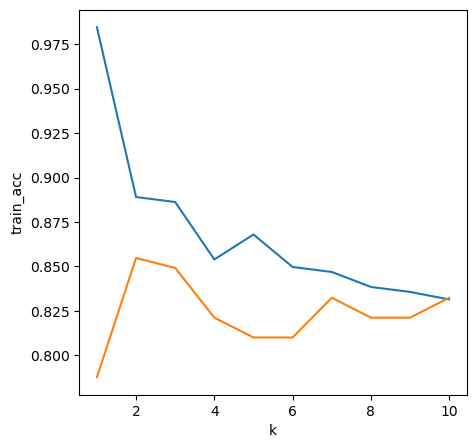

In [18]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.lineplot(x='k', y='train_acc', data=score_df)
sns.lineplot(x='k', y='test_acc', data=score_df)
plt.show()

In [22]:
params = {
    'n_neighbors' : k_param
}
knn = KNeighborsClassifier()
grid_cv = GridSearchCV(knn, param_grid=params, cv=5, n_jobs=-1)

In [24]:
grid_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': range(1, 11)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter ind

In [25]:
grid_cv.best_params_

{'n_neighbors': 4}

In [26]:
print("train_score", grid_cv.score(X_train, y_train))
print("test_score", grid_cv.score(X_test, y_test))

train_score 0.8539325842696629
test_score 0.8212290502793296


In [31]:
params = {
    'n_neighbors' : k_param,
    'metric' : ['manhattan', 'euclidean'],
    'weights' : ['uniform', 'distance']
}
knn = KNeighborsClassifier()
grid_cv = GridSearchCV(knn, param_grid=params, cv=5, n_jobs=-1)

In [32]:
grid_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['manhattan', 'euclidean'], 'n_neighbors': range(1, 11), 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [33]:
grid_cv.best_params_

{'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'uniform'}

In [34]:
print("train_score", grid_cv.score(X_train, y_train))
print("test_score", grid_cv.score(X_test, y_test))

train_score 0.8595505617977528
test_score 0.8212290502793296


In [36]:
knn = KNeighborsClassifier(metric='manhattan', n_neighbors=4, weights='uniform')

In [37]:
knn.fit(X_train, y_train)
print("train_score", knn.score(X_train, y_train))
print("test_score", knn.score(X_test, y_test))

train_score 0.8595505617977528
test_score 0.8212290502793296


### svm 하이퍼 파라미터
* C(cost)
    - cost값이 작으면 과소적합이 발생한다.
        * cost값을 작게하면 훈련 데이터에 대해 어느정도 오류를 허용하게 되며, 새로 들어오는 데이터는 잘 분류할 수 있다
    - cost값이 커지면 과대적합이 발생한다.
        * cost값을 크게하면 훈련 데이터에 대해 오류가 최소화 되지만, 새로 들어오는 데이터는 분류를 잘못할 가능성이 높다는 것이다
     
* gamma
    - 결정 경계에 영향을 끼치는 범위를 조절하는 변수
    - gamma가 크면 과대적합이 될 수 있다
        - gamma가 크면 결정경계에 영향력이 커 결정경계가 복잡해진다
    - gamma가 작으면 과소적합이 될 수 있다.
        - gamma가 작으면 결정경계에 영향력이 미미하여 결정경계가 부드러워진다

In [42]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [39]:
df = pd.read_csv('../data_set/5.스케일링/titanic_cleaning.csv')
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [40]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare'],
      dtype='str')

In [41]:
f = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare']
label = 'Survived'
X, y = df[f], df[label]

In [43]:
scaler = StandardScaler()
scaler.fit(X)
X_scaler = scaler.transform(X)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.2)

In [45]:
svc = SVC(kernel='linear')
svc.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [46]:
print("train score :", svc.score(X_train, y_train))
print("test score :", svc.score(X_test, y_test))

train score : 0.7823033707865169
test score : 0.8044692737430168


In [47]:
svc = SVC(kernel='linear', C=100)
svc.fit(X_train, y_train)

print("train score :", svc.score(X_train, y_train))
print("test score :", svc.score(X_test, y_test))

train score : 0.7823033707865169
test score : 0.8044692737430168


In [49]:
param_cost = [0.01, 0.1, 1, 10, 100]
train_list = []
test_list = []

for cost in param_cost :
    svc = SVC(kernel='linear', C=cost) # kernel linear은 cost만 바꿀 수 있음, 곡선에 대한 영향 주는 gamma 사용할 수 없음
    svc.fit(X_train, y_train)
    train_list.append(svc.score(X_train, y_train))
    test_list.append(svc.score(X_test, y_test))

In [50]:
dic = {
    'param' : param_cost,
    'train_acc' : train_list,
    'test_acc' : test_list
}
score_df = pd.DataFrame(dic)
score_df

,param,train_acc,test_acc
0,0.01,0.782303,0.804469
1,0.10,0.782303,0.804469
2,1.00,0.782303,0.804469
3,10.00,0.782303,0.804469
4,100.00,0.782303,0.804469


In [54]:
param_cost = [0.01, 0.1, 1, 10, 100]
param_gamma = [0.001, 0.01, 0.1, 1, 10]
train_list = []
test_list = []

for idx, cost in enumerate(param_cost) :
    svc = SVC(kernel='rbf', C=cost, gamma=param_gamma[idx]) 
    svc.fit(X_train, y_train)
    train_list.append(svc.score(X_train, y_train))
    test_list.append(svc.score(X_test, y_test))

dic = {
    'param_cost' : param_cost,
    'param_gamma' : param_gamma,
    'train_acc' : train_list,
    'test_acc' : test_list
}
score_df = pd.DataFrame(dic)
score_df

,param_cost,param_gamma,train_acc,test_acc
0,0.01,0.001,0.612360,0.631285
1,0.10,0.010,0.780899,0.804469
2,1.00,0.100,0.834270,0.826816
3,10.00,1.000,0.873596,0.815642
4,100.00,10.000,0.933989,0.776536


In [56]:
params = {
    'C' : param_cost,
    'gamma' : param_gamma
}

svc = SVC(kernel='rbf')

grid_cv = GridSearchCV(svc, param_grid=params, cv=3, n_jobs=-1)

In [57]:
grid_cv.fit(X_train, y_train)
grid_cv.best_params_

{'C': 1, 'gamma': 0.1}

In [58]:
print('train score :', grid_cv.score(X_train, y_train))
print('test score :', grid_cv.score(X_test, y_test))

train score : 0.8342696629213483
test score : 0.8268156424581006


### 랜덤 포레스트 하이퍼 파라미터
* n_estimators
    - 트리의 개수. default=10
    - 트리의 개수가 많이면 성능은 좋아지지만, 시간이 오래 걸릴수 있다.
* max_depth
    - 트리의 최대 깊이. default = None
    - 완벽하게 파라미터값이 결정될 때 까지 분할 또는 min_samples_split보다 작아질 때까지 분할
    - 깊이가 깊어지면 과대적합될 수 있으므로 적절히 제어 필요
* min_samples_leaf
    - 맆노드(자식노드가 없는 노드)가 되기 위해 최소한의 샘플 데이터 수
    - min_samples_split과 함께 과대적합 제어용도
    - 불균형 데이터가 있는 경우 작게 설정하는게 좋다
* min_samples_split
    - 노드를 분할하기 위한 최소한의 샘플 데이터수. default = 2
    - 과적합을 제어하는데 사용
    - 작게 설정할 수록 분할 노드가 많아져 과대적합 가능성 증가

In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

In [60]:
# 타이타닉 데이터ㅔㅅ
df.head(2)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,1,0,3,0,22.0,1,0,7.2500
1,2,1,1,1,38.0,1,0,71.2833


In [62]:
# X, y 타이타닉 데이터
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

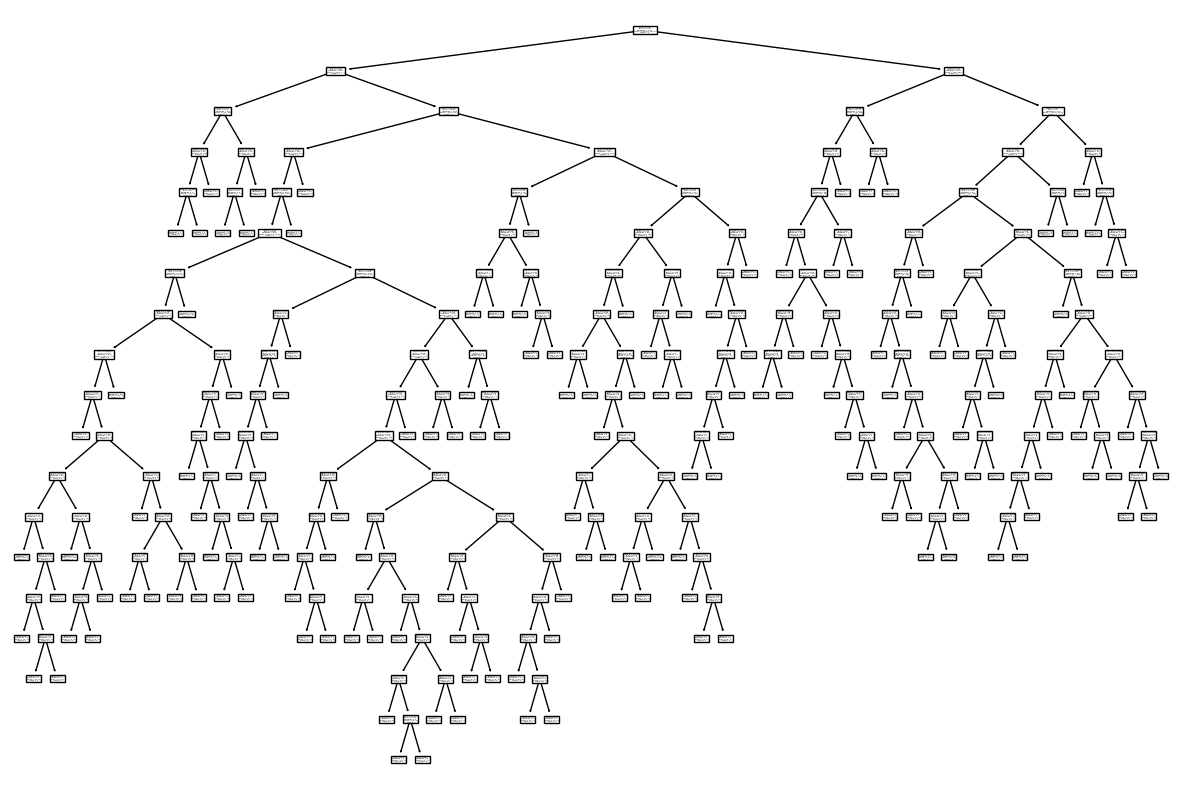

In [67]:
clf = DecisionTreeClassifier() # max_depth = 2
clf = clf.fit(X_train, y_train)
fig = plt.figure(figsize=(15, 10), facecolor='white')
tree.plot_tree(clf, feature_names=f, class_names=list(label))
plt.show()

In [70]:
rfc = RandomForestClassifier(
    n_estimators=100, max_depth=10, min_samples_leaf=4, min_samples_split=100
)
rfc_def = RandomForestClassifier()

In [72]:
rfc.fit(X_train, y_train)
print('train : ', rfc.score(X_train, y_train))
print('test : ', rfc.score(X_test, y_test))

train :  0.8426966292134831
test :  0.776536312849162


In [73]:
rfc_def.fit(X_train, y_train)
print('train : ', rfc_def.score(X_train, y_train))
print('test : ', rfc_def.score(X_test, y_test))

train :  0.9831460674157303
test :  0.7653631284916201


In [74]:
params = {
    'n_estimators' : range(10, 101, 10),
    'max_depth' : range(4, 11, 2),
    'min_samples_leaf' : range(5, 21, 5),
    'min_samples_split' : range(4, 21, 4)
}
rfc = RandomForestClassifier()

In [75]:
grid_cv = GridSearchCV(rfc, param_grid=params, cv=3, n_jobs=-1)

In [76]:
grid_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(4, 11, 2), 'min_samples_leaf': range(5, 21, 5), 'min_samples_split': range(4, 21, 4), 'n_estimators': range(10, 101, 10)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [77]:
print('best params : ', grid_cv.best_params_)

best params :  {'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 4, 'n_estimators': 40}


In [78]:
print('train :', grid_cv.score(X_train, y_train))
print('test :', grid_cv.score(X_test, y_test))

train : 0.875
test : 0.7932960893854749


In [79]:
inputData = [[3, 0, 22.0, 1, 0, 7.2500]]

In [80]:
grid_cv.predict(inputData)

C:\Users\user\anaconda3\envs\ai\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([0])

### 하이퍼파라미터
* n_estimators
    - 학습기의 수 설정.
    - 많으면 예측률은 올라가나 시간이 오래걸릴 수 있음.
* learning_rate
    - GBM이 학습을 진행할 때마다 적용하는 학습률로서 순차적으로 오류 값을 보정해가는 데 적용하는 수 이다
    - 0~1 사이의 값으로 지정한다. default=0.1
    - 너무 작은 값이면 업데이트를 너무 많이 하게 되어 꼼꼼하지만 시간이 오래 걸린다
    - 너무 큰 값이면 최소 오류 값을 찾지 못할 수 있지만 빠르다
* subsample
    - 학습기가 학습에 사용하는 데이터 샘플의 비율(0~1). default=1.
    - 0.5일경우 50%학습데이터를 사용한다는 것이다
    - 과대적합을 줄이려면 작은 값을 적용해야 한다.

In [81]:
from sklearn.ensemble import GradientBoostingClassifier

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [83]:
gbc = GradientBoostingClassifier()
gbc.fit(X_train, y_train)
print('train : ', gbc.score(X_train, y_train))
print('test : ', gbc.score(X_test, y_test))

train :  0.9143258426966292
test :  0.8044692737430168


In [84]:
import numpy as np

In [85]:
params = {
    'learning_rate' : [0.1, 0.3, 0.5, 0.7, 0.9],
    'n_estimators' : [100, 300, 500],
    'subsample' : np.arange(0.1, 1, 0.2) # 실수값은 np를 활용
}

In [86]:
grid_cv = GridSearchCV( gbc, param_grid=params, cv=3, n_jobs=-1 )

In [87]:
grid_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoostingClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.1, 0.3, ...], 'n_estimators': [100, 300, ...], 'subsample': array([0.1, 0....5, 0.7, 0.9])}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is

In [88]:
print('best params : ', grid_cv.best_params_)
print('train :', grid_cv.score(X_train, y_train))
print('test :', grid_cv.score(X_test, y_test))

best params :  {'learning_rate': 0.1, 'n_estimators': 100, 'subsample': np.float64(0.9000000000000001)}
train : 0.9129213483146067
test : 0.7988826815642458


In [89]:
print(gbc.feature_importances_)
X_train.head(1)

[0.15912104 0.48966456 0.14106027 0.02395063 0.00904175 0.17716175]


,Pclass,Sex,Age,SibSp,Parch,Fare
878,3,0,29.699118,0,0,7.8958
